### 1: Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("churn_clean.csv")

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceSegment
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-50,Zero Balance
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-50,Medium Balance
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-50,High Balance
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-50,Zero Balance
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-50,High Balance


### 2: Dataset Information

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
 11  AgeGroup         10000 non-null  str    
 12  BalanceSegment   9999 non-null   str    
dtypes: float64(2), int64(7), str(4)
memory usage: 1015.8 KB


In [18]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [19]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
AgeGroup           0
BalanceSegment     1
dtype: int64

### 3: Customer Churn Distribution

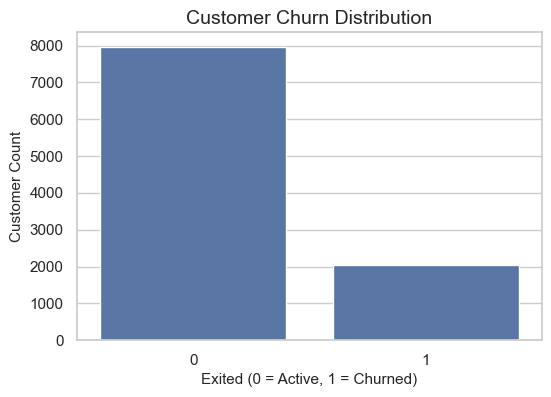

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Active, 1 = Churned)")
plt.ylabel("Customer Count")

plt.show()

### 4: Churn by Geography

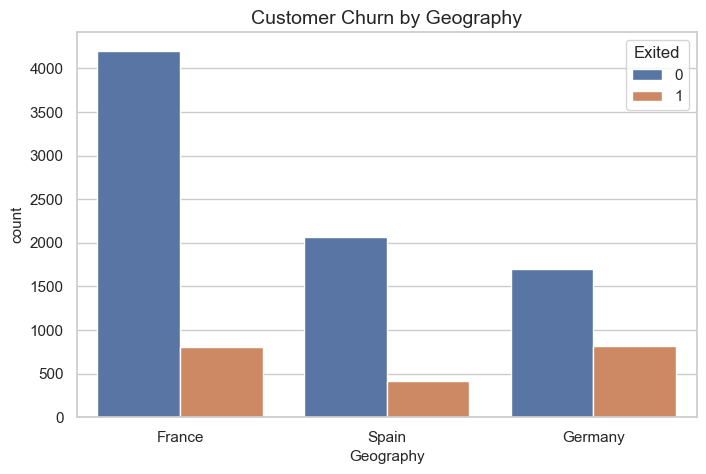

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Geography",
    hue="Exited"
)

plt.title("Customer Churn by Geography")
plt.show()

### 5: Churn by Gender

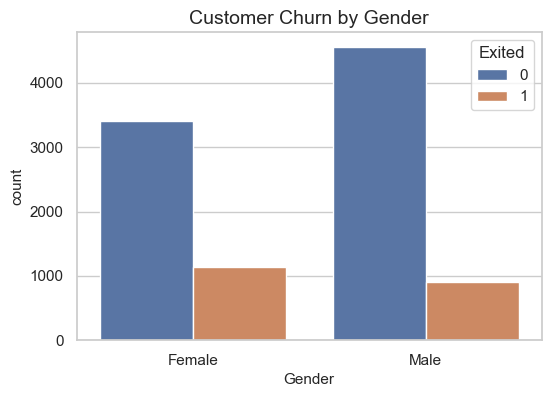

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Exited"
)

plt.title("Customer Churn by Gender")
plt.show()

### 6: Age vs Churn

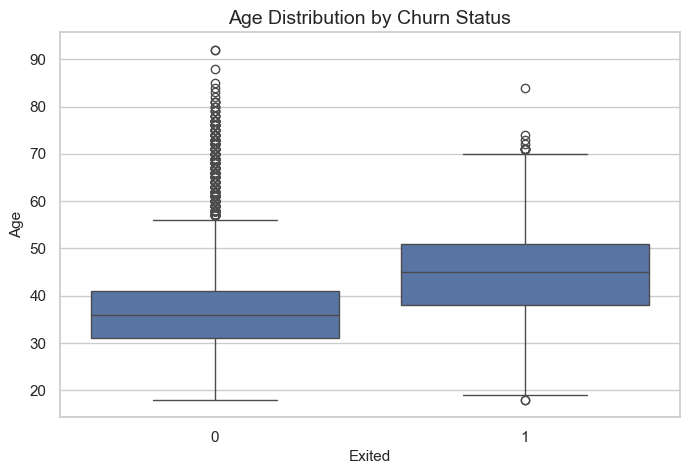

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)

plt.title("Age Distribution by Churn Status")
plt.show()

### 7: Correlation Heatmap

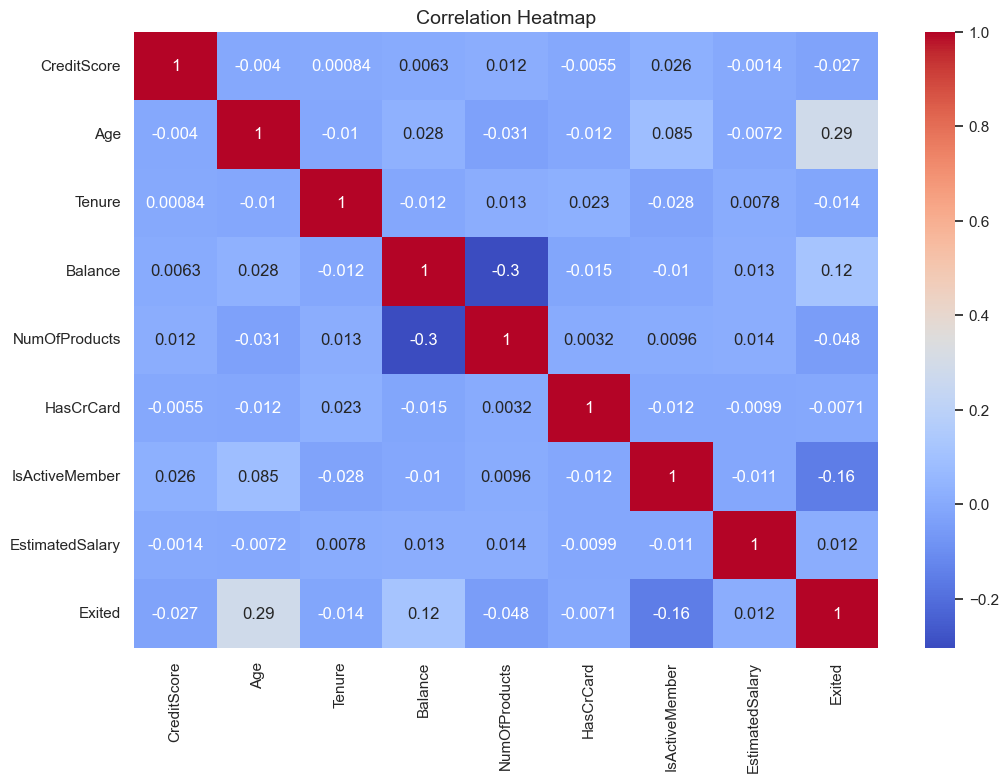

In [24]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### 8: Churn Driver Analysis

In [25]:
churn_analysis = df.groupby("Exited")[[
    "CreditScore",
    "Age",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts"
]].mean()

churn_analysis

,CreditScore,Age,Balance,EstimatedSalary,NumOfProducts
Exited,,,,,
0,651.853196,37.408389,72745.296779,99738.391772,1.544267
1,645.351497,44.837997,91108.539337,101465.677531,1.475209


### 9: High Risk Customers

In [26]:
high_risk = df[
    (df["Age"] > 50) &
    (df["Balance"] > 100000) &
    (df["Exited"] == 1)
]

high_risk.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceSegment
16,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,50+,High Balance
41,465,France,Female,51,8,122522.32,1,0,0,181297.65,1,50+,High Balance
70,738,Germany,Male,58,2,133745.44,4,1,0,28373.86,1,50+,High Balance
127,625,Germany,Male,56,0,148507.24,1,1,0,46824.08,1,50+,High Balance
179,754,Germany,Female,55,3,161608.81,1,1,0,8080.85,1,50+,High Balance


### 10: Save High Risk Customers

In [27]:
high_risk.to_csv(
    "high_risk_customers.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
